# PaySim DL Model Training

Dataset: PaySim Fraud Detection (Engineered Features, Scaled)

| ModelID | Model Type | Notes |
|--------|-----------|------|
| AE_Semi | Autoencoder | Semi-supervised regime, trained on normal transactions only, anomaly score from MSE reconstruction error |
| AE_Supp | Autoencoder | Supervised-style regime, trained on all data, anomaly score from MSE reconstruction error |
| MLP | Multi-Layer Perceptron | Supervised classification, weighted BCE loss to handle class imbalance, 128-64-1 architecture |

In [2]:
import os
import pandas as pd
import numpy as np
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

import warnings
warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)

# --- 1. DATA PREP ---
print("Loading and scaling data...")
df_train = pd.read_parquet('data/paysim_feature_train.parquet')
df_val   = pd.read_parquet('data/paysim_feature_val.parquet')
df_test  = pd.read_parquet('data/paysim_feature_test.parquet')

X_train_raw = df_train.drop(['isFraud'], axis=1, errors='ignore').fillna(-999)
X_val_raw   = df_val.drop(['isFraud'], axis=1, errors='ignore').fillna(-999)
X_test_raw  = df_test.drop(['isFraud'], axis=1, errors='ignore').fillna(-999)
y_train = df_train['isFraud'].values
y_val   = df_val['isFraud'].values
y_test  = df_test['isFraud'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)
del df_train, df_val, df_test, X_train_raw, X_val_raw, X_test_raw; gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. THE AUTOENCODER REGIMES ---
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_ae(train_data, eval_data, device, epochs=10):
    input_dim = train_data.shape[1]              
    model = Autoencoder(input_dim).to(device)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(train_data)),
        batch_size=2048,
        shuffle=True
    )
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        for batch in loader:
            xb = batch[0].to(device)
            loss = loss_fn(model(xb), xb)
            opt.zero_grad()
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        eval_t = torch.from_numpy(eval_data).to(device)   # uses passed eval_data
        recon = model(eval_t)
        scores = torch.mean((eval_t - recon) ** 2, dim=1).cpu().numpy()

    return scores, model

# Regime A: Semi-supervised (Train on NORMAL only)
print(">>> Training AE: Semi-supervised Regime...")
ae_semi_scores, ae_semi_model = train_ae(X_train[y_train == 0], X_test, device)

# Regime B: Supervised-style AE (Train on ALL data)
print(">>> Training AE: Supervised Regime...")
ae_supp_scores, _             = train_ae(X_train,               X_test, device)

# --- 3. SUPERVISED MLP ---
print("\n>>> Training Supervised MLP...")
print("Handling imbalance via weighted loss...")

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)

mlp_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train.astype(np.float32))
    ),
    batch_size=2048,
    shuffle=True
)

class SupervisedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

mlp = SupervisedMLP(X_train.shape[1]).to(device)
mlp_opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
mlp_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

for epoch in range(10):
    mlp.train()
    for xb, yb in mlp_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = mlp(xb).squeeze()
        loss = mlp_criterion(logits, yb)

        mlp_opt.zero_grad()
        loss.backward()
        mlp_opt.step()

    print(f"MLP Epoch {epoch+1}/10 complete")

mlp.eval()
with torch.no_grad():
    test_tensor = torch.from_numpy(X_test).to(device)
    mlp_probs = torch.sigmoid(mlp(test_tensor)).cpu().numpy().flatten()

# --- 4. EVALUATION SUMMARY ---
summary_rows = []

for model_name, scores in {
    'ae_semi_supervised': ae_semi_scores,
    'ae_supervised': ae_supp_scores,
    'mlp_prob': mlp_probs
}.items():
    roc = roc_auc_score(y_test, scores)
    auprc = average_precision_score(y_test, scores)
    summary_rows.append({
        'Model': model_name,
        'ROC-AUC': roc,
        'AUPRC': auprc
    })

summary_df = pd.DataFrame(summary_rows).sort_values('AUPRC', ascending=False)

print("\n--- PAYSIM DL PERFORMANCE RANKING ---")
print(summary_df)

# --- 5. EXPORT ---
results_dict = {
    'actual': y_test,
    'ae_semi_supervised': ae_semi_scores,
    'ae_supervised': ae_supp_scores,
    'mlp_prob': mlp_probs
}

df_final = pd.DataFrame(results_dict)
df_final.to_csv('results/paysim_dl_results.csv', index=False)

print("\nSuccess! Results saved to 'results/paysim_dl_results.csv' with all regimes.")

Loading and scaling data...
>>> Training AE: Semi-supervised Regime...
>>> Training AE: Supervised Regime...

>>> Training Supervised MLP...
Handling imbalance via weighted loss...
MLP Epoch 1/10 complete
MLP Epoch 2/10 complete
MLP Epoch 3/10 complete
MLP Epoch 4/10 complete
MLP Epoch 5/10 complete
MLP Epoch 6/10 complete
MLP Epoch 7/10 complete
MLP Epoch 8/10 complete
MLP Epoch 9/10 complete
MLP Epoch 10/10 complete

--- PAYSIM DL PERFORMANCE RANKING ---
                Model   ROC-AUC     AUPRC
2            mlp_prob  0.974624  0.712297
0  ae_semi_supervised  0.836310  0.206990
1       ae_supervised  0.768972  0.028111

Success! Results saved to 'results/paysim_dl_results.csv' with all regimes.


>>> Generating latent space visualisation...


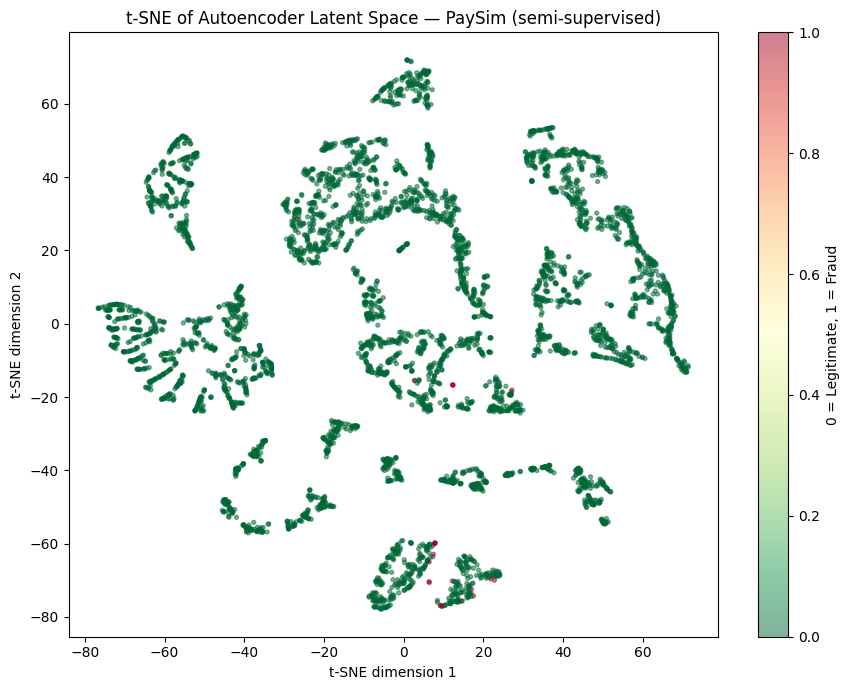

Saved: report/paysim_latent_space_tsne.png


In [3]:
# --- 6. LATENT SPACE VISUALISATION ---
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print(">>> Generating latent space visualisation...")
with torch.no_grad():
    test_t = torch.from_numpy(X_test).to(device)
    latent = ae_semi_model.encoder(test_t).cpu().numpy()

sample_size = 5000
idx = np.random.choice(len(latent), sample_size, replace=False)
latent_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(latent[idx])

plt.figure(figsize=(9, 7))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=y_test[idx], cmap='RdYlGn_r', alpha=0.5, s=8)
plt.colorbar(scatter, label='0 = Legitimate, 1 = Fraud')
plt.title('t-SNE of Autoencoder Latent Space — PaySim (semi-supervised)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('report/paysim_latent_space_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: report/paysim_latent_space_tsne.png")